In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset



In [ ]:
import yfinance as yf
import pandas as pd

# -----------------------------
# CONFIGURACIÓN
# -----------------------------
tickers = ['SAN.MC', 'BBVA.MC']
period = 'max'
interval = '1d'

# -----------------------------
# DESCARGAR DATOS
# -----------------------------
# auto_adjust=False para que Close sea el precio real
data = yf.download(tickers, period=period, interval=interval, auto_adjust=False, actions=True)

# -----------------------------
# FUNCIONES AUXILIARES
# -----------------------------
def add_features(df):
    # Rango diario
    df['range'] = df['high'] - df['low']
    
    # Retornos diarios
    df['return'] = df['close'].pct_change()
    
    # SMA 5 y 10 días
    df['sma_5'] = df['close'].rolling(window=5).mean()
    df['sma_10'] = df['close'].rolling(window=10).mean()
    
    # Volumen relativo (comparado con media de 10 días)
    df['vol_rel'] = df['volume'] / df['volume'].rolling(window=10).mean()
    
    # Solo eliminar filas donde Close sea NaN (no por rolling)
    df = df[df['close'].notna()]
    
    return df

# -----------------------------
# PROCESAR Y GUARDAR POR TICKER
# -----------------------------
for ticker in tickers:
    # Seleccionar columnas de cada ticker usando xs
    df = data.xs(ticker, level=1, axis=1).copy()
    
    # Renombrar columnas a minúsculas
    df.columns = [col.lower() for col in df.columns]
    
    # Añadir features adicionales
    df = add_features(df)
    
    # Guardar CSV
    df.to_csv(f'{ticker.replace(".MC","")}_features.csv')
    print(f'CSV generado: {ticker.replace(".MC","")}_features.csv')


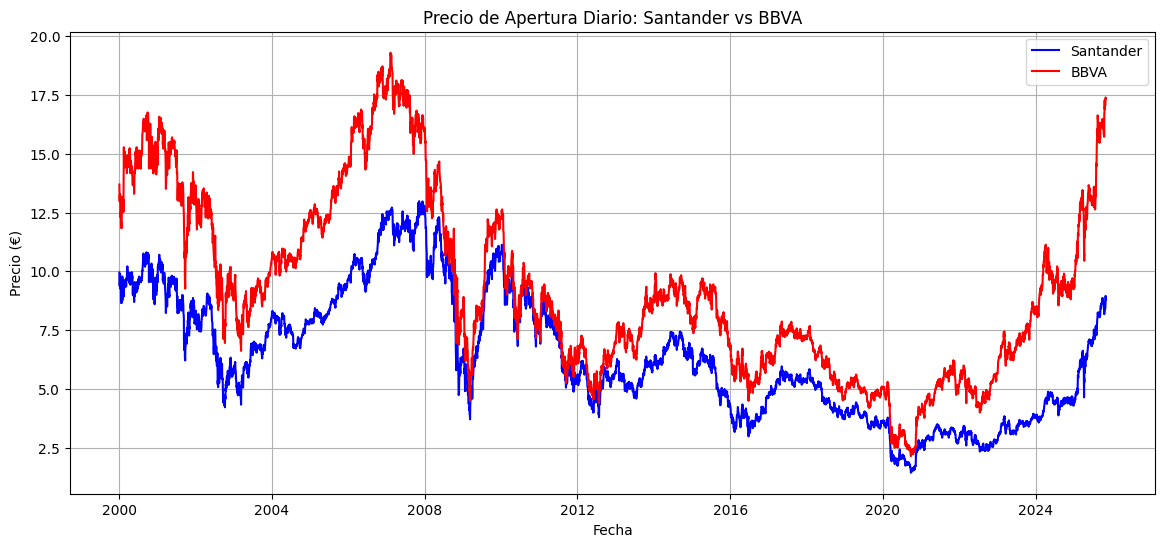

In [2]:
# Cargar CSV
df_san = pd.read_csv('../data/csv/raw/SAN_features.csv', index_col=0, parse_dates=True)
df_bbva = pd.read_csv('../data/csv/raw/BBVA_features.csv', index_col=0, parse_dates=True)

# Graficar precio de apertura
plt.figure(figsize=(14,6))
plt.plot(df_san.index, df_san['open'], label='Santander', color='blue')
plt.plot(df_bbva.index, df_bbva['open'], label='BBVA', color='red')

plt.title('Precio de Apertura Diario: Santander vs BBVA')
plt.xlabel('Fecha')
plt.ylabel('Precio (€)')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\josit\AppData\Local\Temp\ipykernel_39008\2278204862.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_merged = df_merged.fillna(method="ffill")
C:\Users\josit\AppData\Local\Temp\ipykernel_39008\2278204862.py:55: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\josit\CUARTO CURSO\APRENDIZAJE AUTOMATICO\Caso02_Prediccion_BBVA_SANTANDER\env11\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


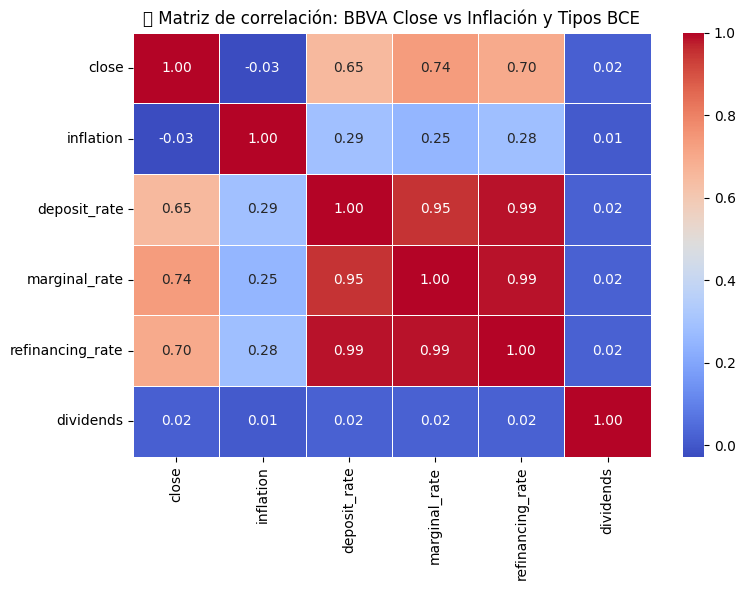


📊 Correlaciones con el precio de cierre (close):
close               1.000000
marginal_rate       0.738839
refinancing_rate    0.695328
deposit_rate        0.654271
dividends           0.016332
inflation          -0.027959
Name: close, dtype: float64


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 📂 1️⃣ Rutas a tus CSV
# ============================================================
ruta_inflacion = "../data/csv/clean/euro_inflation_2000_2025_final.csv"
ruta_tipos = "../data/csv/clean/euro_interest_2000_2025_clean.csv"
ruta_bbva = "../data/csv/raw/BBVA_features.csv"

# ============================================================
# 🧹 2️⃣ Cargar los datasets
# ============================================================
df_infl = pd.read_csv(ruta_inflacion)
df_tipos = pd.read_csv(ruta_tipos)
df_bbva = pd.read_csv(ruta_bbva, index_col=0)

# Normalizar columnas
df_infl.columns = [c.strip().lower().replace(" ", "_") for c in df_infl.columns]
df_tipos.columns = [c.strip().lower().replace(" ", "_") for c in df_tipos.columns]
df_bbva.columns = [c.strip().lower().replace(" ", "_") for c in df_bbva.columns]

# Asegurar tipo datetime
df_infl["date"] = pd.to_datetime(df_infl["date"], errors="coerce")
df_tipos["date"] = pd.to_datetime(df_tipos["date"], errors="coerce")
df_bbva.index = pd.to_datetime(df_bbva.index, errors="coerce")

# ============================================================
# 🔗 3️⃣ Fusionar datasets por fecha
# ============================================================
# Primero unimos inflación y tipos de interés
df_macro = pd.merge(df_infl, df_tipos, on="date", how="outer").sort_values("date")

# Luego unimos con el BBVA
df_merged = pd.merge(df_bbva, df_macro, left_index=True, right_on="date", how="left")

# Forward fill para rellenar días sin datos macroeconómicos
df_merged = df_merged.fillna(method="ffill")

# ============================================================
# 📊 4️⃣ Seleccionar columnas de interés
# ============================================================
cols_corr = ["close", "inflation", "deposit_rate", "marginal_rate", "refinancing_rate", "dividends"]
df_corr = df_merged[cols_corr].dropna()

# ============================================================
# 📈 5️⃣ Calcular y visualizar matriz de correlación
# ============================================================
corr_matrix = df_corr.corr(method="pearson")

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("🔍 Matriz de correlación: BBVA Close vs Inflación y Tipos BCE")
plt.tight_layout()
plt.show()

# ============================================================
# ✅ 6️⃣ Mostrar correlaciones numéricas
# ============================================================
print("\n📊 Correlaciones con el precio de cierre (close):")
print(corr_matrix["close"].sort_values(ascending=False))


## 🔍 Análisis de correlación entre tipos de interés, inflación y el precio del BBVA

En la anterior matriz de correlación se observa una **clara relación positiva entre los tipos de interés del Banco Central Europeo (BCE)** —en particular el tipo de refinanciación, el tipo de depósito y el tipo marginal de préstamo— y la **cotización del BBVA**.

Los resultados muestran coeficientes de correlación próximos a **+0.7**, lo que indica que, históricamente, **cuando el BCE incrementa los tipos de interés, la acción del BBVA tiende a subir**. Este comportamiento tiene una justificación económica clara:  
los bancos comerciales, como el BBVA, **aumentan sus márgenes de beneficio** cuando los tipos de interés oficiales son más altos, ya que la diferencia entre lo que cobran por los préstamos y lo que pagan por los depósitos (margen de interés neto) se amplía.

Por el contrario, la **inflación** muestra una correlación casi nula (−0.03) con el precio de la acción.  
Esto sugiere que la inflación afecta de forma **indirecta** al BBVA, principalmente a través de las decisiones de política monetaria del BCE, más que de forma directa sobre su valor en bolsa.

Dado que los tres tipos de interés (depósito, marginal y refinanciación) presentan una correlación interna muy elevada entre sí (≥ 0.95), se seleccionará **únicamente el tipo de refinanciación (`refinancing_rate`)** como variable representativa para evitar multicolinealidad en el modelo.

---

### 🧠 Integración en el modelo LSTM

A partir de este análisis, incorporaremos el **tipo de refinanciación del BCE como una variable exógena** en nuestro modelo de predicción basado en redes neuronales LSTM.  
De este modo, el modelo no solo aprenderá de la evolución histórica del precio del BBVA, sino que también tendrá en cuenta el **contexto macroeconómico** que más influye en el rendimiento de los bancos.

Esta mejora permitirá **refinar la capacidad predictiva** del modelo, capturando las dinámicas de mercado que vinculan directamente la política monetaria del BCE con el comportamiento bursátil del sector financiero.


In [3]:
import pandas as pd

# ============================================================
# 1️⃣ Cargar datasets base
# ============================================================

# Dataset principal del BBVA extendido
df_bbva = pd.read_csv(
    "../data/csv/clean/BBVA_macro_extended.csv",
    parse_dates=["Date"]
)

# Dataset de inflación
df_inflation = pd.read_csv(
    "../data/csv/clean/euro_inflation_2000_2025_final.csv",
    parse_dates=["date"]
)

# Dataset de tipos de interés (ECB)
df_rates = pd.read_csv(
    "../data/csv/clean/euro_interest_2000_2025_clean.csv",
    parse_dates=["date"]
)

# ============================================================
# 2️⃣ Calcular medias móviles adicionales (30 y 60 días)
# ============================================================

df_bbva = df_bbva.sort_values("Date").copy()
df_bbva["sma_7"]  = df_bbva["close"].rolling(window=7).mean()
df_bbva["sma_30"] = df_bbva["close"].rolling(window=30).mean()
df_bbva["sma_60"] = df_bbva["close"].rolling(window=60).mean()
df_bbva = df_bbva.fillna(method="bfill")

# ============================================================
# 3️⃣ Fusionar inflación (por fecha más cercana o anterior)
# ============================================================

# Alinear por fecha (algunos días del BBVA no estarán en inflación → usamos forward fill)
df_inflation = df_inflation.rename(columns={"date": "Date", "inflation": "inflation_rate"})
df_merged = pd.merge_asof(
    df_bbva.sort_values("Date"),
    df_inflation.sort_values("Date"),
    on="Date",
    direction="backward"
)

# ============================================================
# 4️⃣ Fusionar tipos de interés (deposit, marginal, refinancing)
# ============================================================

df_rates = df_rates.rename(columns={
    "date": "Date",
    "deposit_rate": "deposit_rate",
    "marginal_rate": "marginal_rate",
    "refinancing_rate": "refinancing_rate"
})

df_final = pd.merge_asof(
    df_merged.sort_values("Date"),
    df_rates.sort_values("Date"),
    on="Date",
    direction="backward"
)

# ============================================================
# 5️⃣ Verificar columnas y vista previa
# ============================================================

print("✅ DataFrame final creado correctamente. Columnas disponibles:\n")
print(df_final.columns.tolist())
print("\n🧾 Vista previa del DataFrame final:\n")
#quitar columna adj close de df_final
df_final = df_final.drop(columns=["adj close", "sma_5", "sma_10"])
df_final.head(6635)


✅ DataFrame final creado correctamente. Columnas disponibles:

['Date', 'adj close', 'close', 'dividends', 'high', 'low', 'open', 'stock splits', 'volume', 'range', 'return', 'sma_5', 'sma_10', 'vol_rel', 'eventos_negativos', 'sma_7', 'sma_30', 'sma_60', 'inflation_rate', 'deposit_rate', 'marginal_rate', 'refinancing_rate']

🧾 Vista previa del DataFrame final:



C:\Users\josit\AppData\Local\Temp\ipykernel_39008\2625883406.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bbva = df_bbva.fillna(method="bfill")


,Date,close,dividends,high,low,open,stock splits,volume,range,return,vol_rel,eventos_negativos,sma_7,sma_30,sma_60,inflation_rate,deposit_rate,marginal_rate,refinancing_rate
0,2000-01-03,13.623349,0.0,13.757854,13.594527,13.690602,0.0,8244257,0.163327,-0.026093,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00
1,2000-01-04,13.267874,0.0,13.536882,13.219837,13.450416,0.0,8522096,0.317045,-0.026093,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00
2,2000-01-05,12.970044,0.0,13.210230,12.912399,13.142977,0.0,12159826,0.297831,-0.022447,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00
3,2000-01-06,12.970044,0.0,12.970044,12.970044,12.970044,0.0,0,0.000000,0.000000,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00
4,2000-01-07,13.133370,0.0,13.248659,12.998866,13.248659,0.0,62261944,0.249793,0.012593,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6630,2025-10-27,17.200001,0.0,17.235001,17.004999,17.049999,0.0,6597073,0.230001,0.017752,0.687307,0,17.010714,16.351833,16.130000,2.400000,2.0,2.4,2.15
6631,2025-10-28,17.190001,0.0,17.215000,17.040001,17.070000,0.0,5314738,0.174999,-0.000581,0.550521,0,17.087143,16.385333,16.167667,2.400000,2.0,2.4,2.15
6632,2025-10-29,17.580000,0.0,17.584999,17.055000,17.209999,0.0,10750147,0.529999,0.022688,1.056277,0,17.127857,16.436167,16.206667,2.400000,2.0,2.4,2.15
6633,2025-10-30,17.280001,0.0,17.410000,17.049999,17.389999,0.0,10839276,0.360001,-0.017065,1.053369,0,17.158572,16.471500,16.236417,2.400000,2.0,2.4,2.15


## 📊 Preparación del Dataset Macroeconómico BBVA

En esta fase se ha realizado la integración y limpieza del dataset principal del **BBVA**, incorporando información macroeconómica y mejorando las variables técnicas para el posterior entrenamiento de la red LSTM.

---

### 🧱 1️⃣ Estructura inicial
El dataset original (`BBVA_macro_extended.csv`) contenía información diaria del precio del activo con las siguientes columnas principales:
- `open`, `high`, `low`, `close`: precios de apertura, máximo, mínimo y cierre.
- `volume`: volumen diario de negociación.
- `range`: diferencia diaria entre `high` y `low`.
- `return`: rentabilidad o variación porcentual diaria.
- `sma_5`, `sma_10`: medias móviles cortas.
- `eventos_negativos`: indicador binario (1 = evento global adverso).

---

### ⚙️ 2️⃣ Transformaciones aplicadas

#### 🔹 Sustitución de medias móviles
Se eliminaron las medias móviles de **5 y 10 días**, ya que se consideran demasiado cortas para captar la tendencia general, y se añadieron tres medias móviles más informativas:
- **SMA_7** → corto plazo (una semana laboral).
- **SMA_30** → medio plazo (aprox. un mes).
- **SMA_60** → largo plazo (dos meses).

Estas variables ayudan al modelo a reconocer tendencias y reversiones de precio a diferentes escalas temporales.

---

### 💶 3️⃣ Incorporación de variables macroeconómicas

Se añadieron fuentes de datos externas que afectan directamente a los mercados financieros europeos y, por tanto, al comportamiento de las acciones del BBVA:

- **Inflación (HICP)**: proveniente del *Banco Central Europeo* y de *Eurostat*, expresa la tasa de inflación anual armonizada.
- **Tipos de interés oficiales del BCE**:
  - `deposit_rate`: tipo de la facilidad de depósito.
  - `refinancing_rate`: tipo principal de refinanciación.
  - `marginal_rate`: tipo de facilidad marginal de crédito.

Estos indicadores reflejan el contexto económico general (política monetaria, estabilidad financiera y expectativas de inflación) y se alinearon por fecha con los datos del BBVA mediante un *merge asof* (unión por fecha más reciente anterior).

---

### ⚠️ 4️⃣ Limpieza adicional

- Se eliminó la columna `adjusted_close`, ya que el ajuste por dividendos no aporta información útil en este contexto predictivo de corto plazo.  
- Se aplicó `bfill()` para rellenar pequeños huecos temporales en las series de medias móviles y datos macroeconómicos.  
- Los **eventos negativos** ya estaban integrados en el dataset, indicando periodos de crisis o perturbaciones globales.

---

### 📈 5️⃣ Resultado final

El dataset resultante (`df_final`) combina ahora información **técnica y macroeconómica** diaria, ideal para alimentar un modelo LSTM multivariable.

| Date | open | high | low | close | volume | range | return | sma_7 | sma_30 | sma_60 | inflation_rate | deposit_rate | marginal_rate | refinancing_rate | eventos_negativos |
|------|------|------|-----|-------|---------|--------|---------|--------|---------|---------|----------------|----------------|----------------|-------------------|-------------------|
| 2000-01-03 | 12.55 | 12.70 | 12.48 | 12.64 | 5320000 | 0.22 | 0.013 | 12.54 | 12.61 | 12.63 | 1.9 | 2.0 | 4.0 | 3.0 | 0 |

---

## ✅ En resumen
El nuevo dataset está completamente preparado para el entrenamiento de la red neuronal LSTM, incluyendo información tanto **micro (propia del activo)** como **macro (entorno económico global)**.




In [4]:
import pandas as pd
import numpy as np

# ============================================================
# 🧹 Limpieza avanzada de 'volume', 'range' y 'return'
# ============================================================

cols_to_check = ["volume", "range", "return"]

# 1️⃣ Asegurarnos de que todas las columnas existen
for col in cols_to_check:
    if col not in df_final.columns:
        raise KeyError(f"La columna '{col}' no existe en el DataFrame.")

# 2️⃣ Limpieza y conversión robusta a numérico
for col in cols_to_check:
    # Eliminar espacios y comas (por si hay valores tipo "1,000")
    df_final[col] = (
        df_final[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
    )
    # Convertir a float, forzando errores a NaN
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce")

# 3️⃣ Reemplazar ceros por NA (para poder interpolar)
df_final[cols_to_check] = df_final[cols_to_check].replace(0, np.nan)

# 4️⃣ Interpolación lineal (solo columnas numéricas)
df_final[cols_to_check] = df_final[cols_to_check].interpolate(method="linear")

# 5️⃣ Rellenar huecos iniciales y finales con el valor más cercano
df_final[cols_to_check] = df_final[cols_to_check].bfill().ffill()

# 6️⃣ Verificación final
for col in cols_to_check:
    dtype = df_final[col].dtype
    missing = df_final[col].isna().sum()
    zeros = (df_final[col] == 0).sum()
    print(f"✅ {col}: dtype={dtype}, {missing} NA, {zeros} ceros")

# 7️⃣ Vista previa
print("\n🧾 Vista rápida tras limpieza:")
print(df_final[cols_to_check].head(10))


✅ volume: dtype=float64, 0 NA, 0 ceros
✅ range: dtype=float64, 0 NA, 0 ceros
✅ return: dtype=float64, 0 NA, 0 ceros

🧾 Vista rápida tras limpieza:
       volume     range    return
0   8244257.0  0.163327 -0.026093
1   8522096.0  0.317045 -0.026093
2  12159826.0  0.297831 -0.022447
3  37210885.0  0.273812 -0.004927
4  62261944.0  0.249793  0.012593
5  58740351.0  0.374691 -0.016094
6   6761292.0  0.355474 -0.020074
7   8266754.0  0.249794 -0.011381
8   9372669.0  0.432335 -0.024559
9   8538333.0  0.249793  0.019670


In [5]:
# ============================================================
# 🔍 Comprobar si existen valores nulos en el DataFrame
# ============================================================

# 1️⃣ Mostrar número total de valores nulos por columna
print("🔎 Valores nulos por columna:")
print(df_final.isna().sum())

# 2️⃣ Si quieres ver solo las columnas que sí tienen nulos:
print("\n⚠️ Columnas con valores nulos:")
print(df_final.columns[df_final.isna().any()].tolist())

# 3️⃣ Verificar si hay alguno en todo el DataFrame
if df_final.isna().any().any():
    print("\n❌ Aún existen valores nulos en el DataFrame.")
else:
    print("\n✅ No hay valores nulos en el DataFrame.")

# 4️⃣ (Opcional) Mostrar algunas filas que contienen NaN
print("\n🧾 Ejemplo de filas con nulos (si existen):")
print(df_final[df_final.isna().any(axis=1)].head(5))


🔎 Valores nulos por columna:
Date                 0
close                0
dividends            0
high                 0
low                  0
open                 0
stock splits         0
volume               0
range                0
return               0
vol_rel              0
eventos_negativos    0
sma_7                0
sma_30               0
sma_60               0
inflation_rate       0
deposit_rate         0
marginal_rate        0
refinancing_rate     0
dtype: int64

⚠️ Columnas con valores nulos:
[]

✅ No hay valores nulos en el DataFrame.

🧾 Ejemplo de filas con nulos (si existen):
Empty DataFrame
Columns: [Date, close, dividends, high, low, open, stock splits, volume, range, return, vol_rel, eventos_negativos, sma_7, sma_30, sma_60, inflation_rate, deposit_rate, marginal_rate, refinancing_rate]
Index: []


In [6]:
# Crear columna binaria (1 = hay dividendo, 0 = no hay)
df_final["dividends_f"] = np.where(df_final["dividends"] > 0, 1, 0)

# Verificar los primeros valores
print(df_final[["Date", "dividends_f", "dividends"]].head(15))
#eliminar columna dividends
df_final = df_final.drop(columns=["dividends"])


         Date  dividends_f  dividends
0  2000-01-03            0   0.000000
1  2000-01-04            0   0.000000
2  2000-01-05            0   0.000000
3  2000-01-06            0   0.000000
4  2000-01-07            0   0.000000
5  2000-01-10            0   0.000000
6  2000-01-11            0   0.000000
7  2000-01-12            1   0.103088
8  2000-01-13            0   0.000000
9  2000-01-14            0   0.000000
10 2000-01-17            0   0.000000
11 2000-01-18            0   0.000000
12 2000-01-19            0   0.000000
13 2000-01-20            0   0.000000
14 2000-01-21            0   0.000000


In [7]:
df_final.head(6635)

,Date,close,high,low,open,stock splits,volume,range,return,vol_rel,eventos_negativos,sma_7,sma_30,sma_60,inflation_rate,deposit_rate,marginal_rate,refinancing_rate,dividends_f
0,2000-01-03,13.623349,13.757854,13.594527,13.690602,0.0,8244257.0,0.163327,-0.026093,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00,0
1,2000-01-04,13.267874,13.536882,13.219837,13.450416,0.0,8522096.0,0.317045,-0.026093,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00,0
2,2000-01-05,12.970044,13.210230,12.912399,13.142977,0.0,12159826.0,0.297831,-0.022447,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00,0
3,2000-01-06,12.970044,12.970044,12.970044,12.970044,0.0,37210885.0,0.273812,-0.004927,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00,0
4,2000-01-07,13.133370,13.248659,12.998866,13.248659,0.0,62261944.0,0.249793,0.012593,0.466914,0,13.078470,12.661004,13.667384,1.933573,2.0,4.0,3.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6630,2025-10-27,17.200001,17.235001,17.004999,17.049999,0.0,6597073.0,0.230001,0.017752,0.687307,0,17.010714,16.351833,16.130000,2.400000,2.0,2.4,2.15,0
6631,2025-10-28,17.190001,17.215000,17.040001,17.070000,0.0,5314738.0,0.174999,-0.000581,0.550521,0,17.087143,16.385333,16.167667,2.400000,2.0,2.4,2.15,0
6632,2025-10-29,17.580000,17.584999,17.055000,17.209999,0.0,10750147.0,0.529999,0.022688,1.056277,0,17.127857,16.436167,16.206667,2.400000,2.0,2.4,2.15,0
6633,2025-10-30,17.280001,17.410000,17.049999,17.389999,0.0,10839276.0,0.360001,-0.017065,1.053369,0,17.158572,16.471500,16.236417,2.400000,2.0,2.4,2.15,0


In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Copia del DF
data = df_final.copy()

# Columnas continuas a escalar
features_to_scale = [
    "open", "high", "low", "close",
    "volume",
    "sma_7", "sma_30", "sma_60"
]

# Columnas que dejamos sin escalar o se escalan aparte
macro_vars = ["inflation_rate", "deposit_rate", "marginal_rate", "refinancing_rate"]
binary_vars = ["eventos_negativos", "dividends_f"]
rate_vars = ["return"]

scaler_cont = MinMaxScaler()
data[features_to_scale] = scaler_cont.fit_transform(data[features_to_scale])

# Normalización suave (dividir entre 10) de las macro, para mantener coherencia
data[macro_vars] = data[macro_vars] / 10

# Dejamos 'return' y 'eventos_negativos' como están
print("✅ Datos escalados con criterio económico")


✅ Datos escalados con criterio económico


In [17]:
#eliminar stock splits
data = data.drop(columns=["stock splits"])


In [18]:
data.head()

,Date,close,high,low,open,volume,range,return,vol_rel,eventos_negativos,sma_7,sma_30,sma_60,inflation_rate,deposit_rate,marginal_rate,refinancing_rate,dividends_f
0,2000-01-03,0.669129,0.668208,0.672964,0.673246,0.011572,0.163327,-0.026093,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
1,2000-01-04,0.648380,0.655404,0.650974,0.659234,0.012035,0.317045,-0.026093,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
2,2000-01-05,0.630995,0.636476,0.632930,0.641299,0.018102,0.297831,-0.022447,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
3,2000-01-06,0.630995,0.622558,0.636313,0.631210,0.059882,0.273812,-0.004927,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
4,2000-01-07,0.640529,0.638703,0.638005,0.647464,0.101662,0.249793,0.012593,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ============================================================
# CONFIGURACIÓN INICIAL
# ============================================================
lookback = 60   # número de días que "mira" hacia atrás
target_col = "close"   # lo que queremos predecir

# Columnas de entrada (todas menos el target)
feature_cols = [
    "open","high","low","volume",
    "range","return","vol_rel",
    "eventos_negativos","sma_7","sma_30","sma_60",
    "inflation_rate","deposit_rate","marginal_rate","refinancing_rate",
    "dividends_f"
]

# ============================================================
# CONVERTIR DATAFRAME A ARRAYS
# ============================================================
X_all = data[feature_cols].astype(float).values
y_all = data[target_col].astype(float).values

# ============================================================
# FUNCIÓN PARA CREAR SECUENCIAS TEMPORALES
# ============================================================
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:(i + lookback)])   # ventana de 60 días
        ys.append(y[i + lookback])       # predicción del siguiente día
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_all, y_all, lookback)
print("✅ Secuencias creadas:", X_seq.shape, y_seq.shape)

# ============================================================
# DATASET COMPLETO DE ENTRENAMIENTO
# ============================================================
X_train_t = torch.tensor(X_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_seq, dtype=torch.float32).view(-1, 1)  # aseguramos shape (N, 1)

train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

print(f"✅ DataLoader completo listo: {len(train_ds)} secuencias de entrenamiento")


✅ Secuencias creadas: (6575, 60, 16) (6575,)
✅ DataLoader completo listo: 6575 secuencias de entrenamiento


In [10]:
import torch
import torch.nn as nn
import numpy as np

# ============================================================
# BLOQUE 2 — MODELO LSTM + ENTRENAMIENTO CON EARLY STOPPING
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# ------------------------------------------------------------
# DEFINICIÓN DEL MODELO
# ------------------------------------------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # tomamos la última salida temporal
        out = self.fc(out)
        return out


# ------------------------------------------------------------
# CONFIGURACIÓN Y ENTRENAMIENTO
# ------------------------------------------------------------
input_size = X_seq.shape[2]   # número de columnas/features
model = LSTMModel(input_size=input_size, hidden_size=128, num_layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 1000
PATIENCE = 100

best_loss = np.inf
epochs_no_improve = 0
best_state = None

print("🚀 Entrenando modelo LSTM...\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    epoch_loss = np.mean(epoch_losses)

    # Validación interna (opcional, aquí usamos train_loss para early stopping)
    if epoch_loss < best_loss - 1e-6:
        best_loss = epoch_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch:03d} | Loss: {epoch_loss:.6f} | No mejora: {epochs_no_improve}")

    if epochs_no_improve >= PATIENCE:
        print(f"\n⏹️ Early stopping activado tras {epoch} epochs (mejor pérdida: {best_loss:.6f})")
        break


Usando dispositivo: cuda
🚀 Entrenando modelo LSTM...

Epoch 001 | Loss: 0.014755 | No mejora: 0
Epoch 002 | Loss: 0.000707 | No mejora: 0
Epoch 003 | Loss: 0.000552 | No mejora: 0
Epoch 004 | Loss: 0.000434 | No mejora: 0
Epoch 005 | Loss: 0.000364 | No mejora: 0
Epoch 006 | Loss: 0.000335 | No mejora: 0
Epoch 007 | Loss: 0.000338 | No mejora: 1
Epoch 008 | Loss: 0.000322 | No mejora: 0
Epoch 009 | Loss: 0.000285 | No mejora: 0
Epoch 010 | Loss: 0.000301 | No mejora: 1
Epoch 011 | Loss: 0.000261 | No mejora: 0
Epoch 012 | Loss: 0.000334 | No mejora: 1
Epoch 013 | Loss: 0.000291 | No mejora: 2
Epoch 014 | Loss: 0.000246 | No mejora: 0
Epoch 015 | Loss: 0.000225 | No mejora: 0
Epoch 016 | Loss: 0.000220 | No mejora: 0
Epoch 017 | Loss: 0.000239 | No mejora: 1
Epoch 018 | Loss: 0.000228 | No mejora: 2
Epoch 019 | Loss: 0.000238 | No mejora: 3
Epoch 020 | Loss: 0.000252 | No mejora: 4
Epoch 021 | Loss: 0.000233 | No mejora: 5
Epoch 022 | Loss: 0.000206 | No mejora: 0
Epoch 023 | Loss: 0.00

In [11]:

# ------------------------------------------------------------
# GUARDAR EL MEJOR MODELO
# ------------------------------------------------------------
if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), "best_bbva_lstm.pth")
    print("\n✅ Modelo óptimo guardado como 'best_bbva_lstm.pth'")



✅ Modelo óptimo guardado como 'best_bbva_lstm.pth'


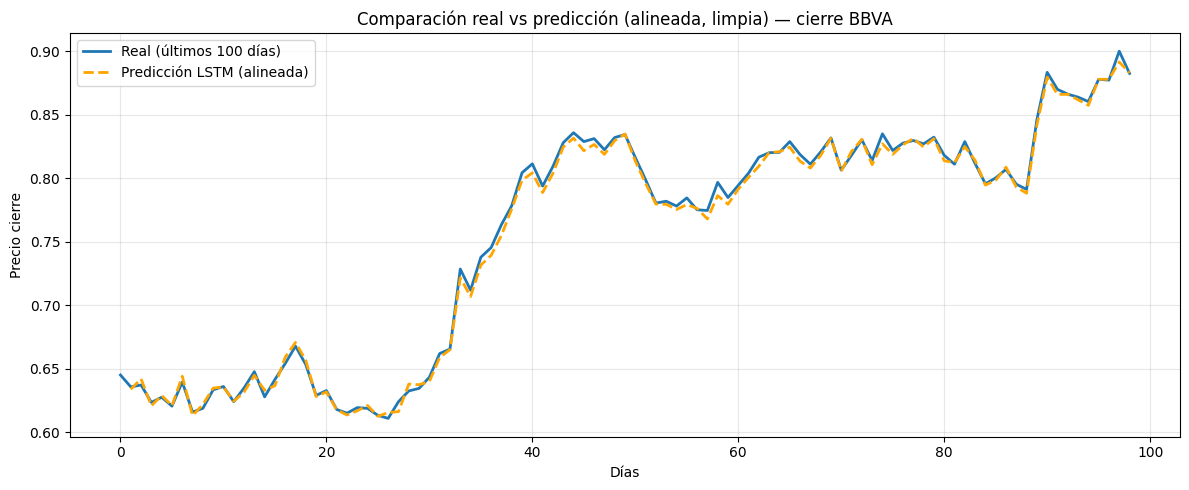

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ============================================================
# BLOQUE — GRÁFICO ALINEADO (CORRECCIÓN DE DESFASE)
# ============================================================

model.eval()

n_future = 100
X_recent = X_seq[-(n_future):]
y_recent_real = y_seq[-(n_future):]

# Predicción paso a paso
preds = []
with torch.no_grad():
    for X_batch in torch.tensor(X_recent, dtype=torch.float32).to(device):
        y_pred = model(X_batch.unsqueeze(0))
        preds.append(y_pred.cpu().numpy().flatten()[0])

preds = np.array(preds)

# Si los datos están escalados, deshacer escala
# preds_inv = scaler_y.inverse_transform(preds.reshape(-1, 1)).flatten()
# y_real_inv = scaler_y.inverse_transform(y_recent_real.reshape(-1, 1)).flatten()
preds_inv = preds
y_real_inv = y_recent_real

# ⚙️ Desfase: movemos las predicciones un día adelante para que
# el valor predicho para el día t se alinee con el real del día t+1
preds_shifted = np.roll(preds_inv, 0)
preds_shifted[0] = np.nan  # primer valor no tiene predicción previa

# Cortamos el último punto sin valor real
preds_shifted = preds_shifted[:-1]
y_real_inv = y_real_inv[:-1]

plt.figure(figsize=(12,5))
plt.plot(y_real_inv, label="Real (últimos 100 días)", linewidth=2)
plt.plot(preds_shifted, label="Predicción LSTM (alineada)", linewidth=2, linestyle='--', color='orange')
plt.title("Comparación real vs predicción (alineada, limpia) — cierre BBVA")
plt.xlabel("Días")
plt.ylabel("Precio cierre")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
# ============================================================
# 🔮 PREDICCIÓN 5 DÍAS FUTUROS - coherente en escala real
# ============================================================

forecast_start = pd.to_datetime("2025-11-01")
forecast_end   = pd.to_datetime("2025-11-07")
dates_fc = pd.date_range(forecast_start, forecast_end, freq="D")

target_col = "close"
feature_cols = [
    "open","high","low","volume","range","return","vol_rel","eventos_negativos",
    "sma_7","sma_30","sma_60","inflation_rate","deposit_rate","marginal_rate",
    "refinancing_rate","dividends_f"
]
# ⚠️ Sin 'close' en features_to_scale (es el target)
features_to_scale = ["close", "open","high","low","volume","sma_7","sma_30","sma_60"]
macro_vars = ["inflation_rate","deposit_rate","marginal_rate","refinancing_rate"]
binary_vars = ["eventos_negativos","dividends_f"]
rate_vars = ["return"]
lookback = 60

# ============ utilidades ============
def recompute_derived(df):
    df = df.copy()
    df["return"] = df[target_col].pct_change()
    df["sma_7"]  = df[target_col].rolling(7, min_periods=1).mean()
    df["sma_30"] = df[target_col].rolling(30, min_periods=1).mean()
    df["sma_60"] = df[target_col].rolling(60, min_periods=1).mean()
    vol_ma10 = df["volume"].rolling(10, min_periods=1).mean().replace(0, np.nan)
    df["vol_rel"] = (df["volume"] / vol_ma10.replace(0, np.nan)).fillna(method="ffill").fillna(1.0)
    base = df["open"].replace(0, np.nan)
    df["range"] = ((df["high"] - df["low"]) / base).fillna(0.0)
    return df

def recent_sigma(df):
    s = df["return"].tail(14).std(skipna=True)
    return float(s) if np.isfinite(s) else 0.0

def recent_vol(df):
    v = df["volume"].tail(20).mean()
    return float(v) if np.isfinite(v) else float(df["volume"].iloc[-1])

def estimate_hilo(prev_open, close_pred, sigma):
    band = 0.4 * abs(sigma if np.isfinite(sigma) else 0.0)
    hi = max(prev_open, close_pred) * (1 + band)
    lo = min(prev_open, close_pred) * (1 - band)
    lo = min(lo, hi * 0.999)
    return hi, lo

def fill_exogenous(df_all, date):
    row = {}
    for col in ["inflation_rate","deposit_rate","marginal_rate","refinancing_rate","dividends_f"]:
        if col in df_all.columns:
            if (date in df_all.index) and pd.notna(df_all.loc[date, col]):
                row[col] = float(df_all.loc[date, col])
            else:
                row[col] = float(df_all[col].loc[:date].ffill().iloc[-1])
        else:
            row[col] = 0.0
    return row

def predict_close_scaled(window_real_df):
    """
    Recibe la ventana en escala REAL (€). Añade una columna temporal 'close'
    para que el scaler vea las mismas 8 columnas del entrenamiento.
    """
    X = window_real_df.copy()

    # --- Añadir columna temporal 'close' para el scaler ---
    if "close" not in X.columns:
        X["close"] = X[target_col]  # por si acaso

    # Extraer las 8 columnas exactas en el mismo orden del fit original
    scaler_cols = ["open","high","low","close","volume","sma_7","sma_30","sma_60"]

    # Aplicar transformación con las 8 columnas
    X_scaled_full = pd.DataFrame(
        scaler_cont.transform(X[scaler_cols]),
        columns=scaler_cols,
        index=X.index
    )

    # Reemplazar solo las features necesarias (sin alterar 'close' real)
    X[scaler_cols] = X_scaled_full[scaler_cols]

    # Escalar macro igual que en el entrenamiento
    X[macro_vars] = X[macro_vars] / 10.0

    # Ordenar columnas en el mismo orden del modelo (sin el close target)
    Xn = X[feature_cols].values

    x_t = torch.tensor(Xn, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        y_hat_scaled = model(x_t).cpu().numpy().reshape(-1)
    return float(y_hat_scaled[0])


# ============ preparar data_real en € ============
data_real = data.copy()

# Si tu DF tiene 'Date' como columna:
if "Date" in data_real.columns:
    data_real["Date"] = pd.to_datetime(data_real["Date"])
    data_real = data_real.set_index("Date")
if not isinstance(data_real.index, pd.DatetimeIndex):
    data_real.index = pd.to_datetime(data_real.index)

# ⚠️ Asegúrate de que data_real esté en €:
# - Si 'data' venía escalado en features_to_scale, inviértelo con tu scaler_cont (7 cols)
#   Si no lo estaba, comenta estas dos líneas.
try:
    data_real[features_to_scale] = scaler_cont.inverse_transform(data_real[features_to_scale])
except Exception:
    # Si ya está en real, no pasa nada
    pass

# Macro a escala real (deshacer /10 si venía escalado)
if (data_real[macro_vars].abs().max().max() <= 5):  # heurística simple
    data_real[macro_vars] = data_real[macro_vars] * 10.0

# ============ histórico y límites para desescalar el target ============
last_real_date = pd.to_datetime("2025-10-31")
hist = data_real.loc[:last_real_date].copy()
hist = recompute_derived(hist)

# y_min / y_max del close en escala real (para desescalar el output del modelo)
y_min = float(hist["close"].min())
y_max = float(hist["close"].max())

# ============ bucle de forecast en escala real ============
synthetic_rows = []
close_scaled_preds = []

for d in dates_fc:
    # Ventana real (60 últimos)
    window_real = pd.concat([hist] + synthetic_rows, axis=0) if synthetic_rows else hist
    window_real = window_real.tail(lookback).copy()

    # Predicción en 0–1 con la ventana REAL (se escala internamente)
    c_scaled = predict_close_scaled(window_real)
    close_scaled_preds.append(c_scaled)

    # Desescalar a €
    # Desescalar a € con el mismo scaler del entrenamiento
    close_min = scaler_cont.data_min_[features_to_scale.index("close")]
    close_max = scaler_cont.data_max_[features_to_scale.index("close")]
    close_pred = close_min + c_scaled * (close_max - close_min)

    # Generar resto del día en €
    prev_close = float(window_real["close"].iloc[-1])
    open_d = prev_close
    sigma = recent_sigma(window_real)
    hi_d, lo_d = estimate_hilo(open_d, close_pred, sigma)
    vol_d = recent_vol(window_real)

    new_row = {
        "open": open_d,
        "high": hi_d,
        "low": lo_d,
        "close": close_pred,
        "volume": vol_d,
        "eventos_negativos": 0.0,
    }
    new_row.update(fill_exogenous(data_real, d))

    # Recalcular derivados en REAL para la siguiente iteración
    tmp = pd.concat([window_real, pd.DataFrame([new_row], index=[d])], axis=0)
    tmp = recompute_derived(tmp)
    synthetic_rows.append(tmp.iloc[[-1]].copy())

# Resultado final SOLO en REAL (nada en 0–1)
fc_df = pd.concat(synthetic_rows).loc[dates_fc, feature_cols + [target_col]]


C:\Users\josit\AppData\Local\Temp\ipykernel_39008\2883996750.py:30: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["vol_rel"] = (df["volume"] / vol_ma10.replace(0, np.nan)).fillna(method="ffill").fillna(1.0)
C:\Users\josit\AppData\Local\Temp\ipykernel_39008\2883996750.py:30: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["vol_rel"] = (df["volume"] / vol_ma10.replace(0, np.nan)).fillna(method="ffill").fillna(1.0)
C:\Users\josit\AppData\Local\Temp\ipykernel_39008\2883996750.py:30: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["vol_rel"] = (df["volume"] / vol_ma10.replace(0, np.nan)).fillna(method="ffill").fillna(1.0)
C:\Users\josit\AppData\Local\Temp\ipykernel_39008\2883996750.py:30: FutureWarning: Series.fillna with '

In [30]:
fc_df

,open,high,low,volume,range,return,vol_rel,eventos_negativos,sma_7,sma_30,sma_60,inflation_rate,deposit_rate,marginal_rate,refinancing_rate,dividends_f,close
2025-11-01,17.433916,17.584063,16.928565,8.272016e+06,0.037599,-0.020551,1.074253,0.0,17.236218,16.540793,16.276523,2.4,2.0,2.4,2.15,0.0,17.075626
2025-11-02,17.075626,17.481354,16.920244,8.417138e+06,0.032860,0.014529,1.076406,0.0,17.296948,16.579144,16.302619,2.4,2.0,2.4,2.15,0.0,17.323714
2025-11-03,17.323714,17.645036,17.169231,8.529565e+06,0.027466,0.009546,1.070557,0.0,17.338419,16.616003,16.327052,2.4,2.0,2.4,2.15,0.0,17.489079
2025-11-04,17.489079,17.849340,17.334766,8.657013e+06,0.029423,0.011673,1.035397,0.0,17.410484,16.669006,16.349551,2.4,2.0,2.4,2.15,0.0,17.693226
2025-11-05,17.693226,17.808924,17.522212,8.840443e+06,0.016205,-0.003147,1.030280,0.0,17.418848,16.708146,16.368871,2.4,2.0,2.4,2.15,0.0,17.637546
2025-11-06,17.637546,17.730420,17.404873,8.938895e+06,0.018458,-0.007968,1.014078,0.0,17.450016,16.750105,16.387850,2.4,2.0,2.4,2.15,0.0,17.497007
2025-11-07,17.497007,17.678488,17.407603,9.206622e+06,0.015482,0.005236,1.000286,0.0,17.472116,16.791783,16.407688,2.4,2.0,2.4,2.15,0.0,17.588615


In [31]:
# quiero poner como indice la columna Date en data
if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.set_index("Date")


In [32]:
data.head(10)


,close,high,low,open,stock splits,volume,range,return,vol_rel,eventos_negativos,sma_7,sma_30,sma_60,inflation_rate,deposit_rate,marginal_rate,refinancing_rate,dividends_f
Date,,,,,,,,,,,,,,,,,,
2000-01-03,0.669129,0.668208,0.672964,0.673246,0.0,0.011572,0.163327,-0.026093,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
2000-01-04,0.648380,0.655404,0.650974,0.659234,0.0,0.012035,0.317045,-0.026093,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
2000-01-05,0.630995,0.636476,0.632930,0.641299,0.0,0.018102,0.297831,-0.022447,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
2000-01-06,0.630995,0.622558,0.636313,0.631210,0.0,0.059882,0.273812,-0.004927,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
2000-01-07,0.640529,0.638703,0.638005,0.647464,0.0,0.101662,0.249793,0.012593,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
2000-01-10,0.628191,0.640373,0.632366,0.649145,0.0,0.095789,0.374691,-0.016094,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
2000-01-11,0.613050,0.618105,0.610940,0.625606,0.0,0.009099,0.355474,-0.020074,0.466914,0,0.641515,0.633158,0.713054,0.193357,0.2,0.4,0.3,0
2000-01-12,0.604638,0.603631,0.602482,0.612154,0.0,0.011610,0.249794,-0.011381,0.466914,0,0.632162,0.633158,0.713054,0.193357,0.2,0.4,0.3,1
2000-01-13,0.586692,0.597507,0.585566,0.603187,0.0,0.013454,0.432335,-0.024559,0.466914,0,0.623217,0.633158,0.713054,0.193357,0.2,0.4,0.3,0


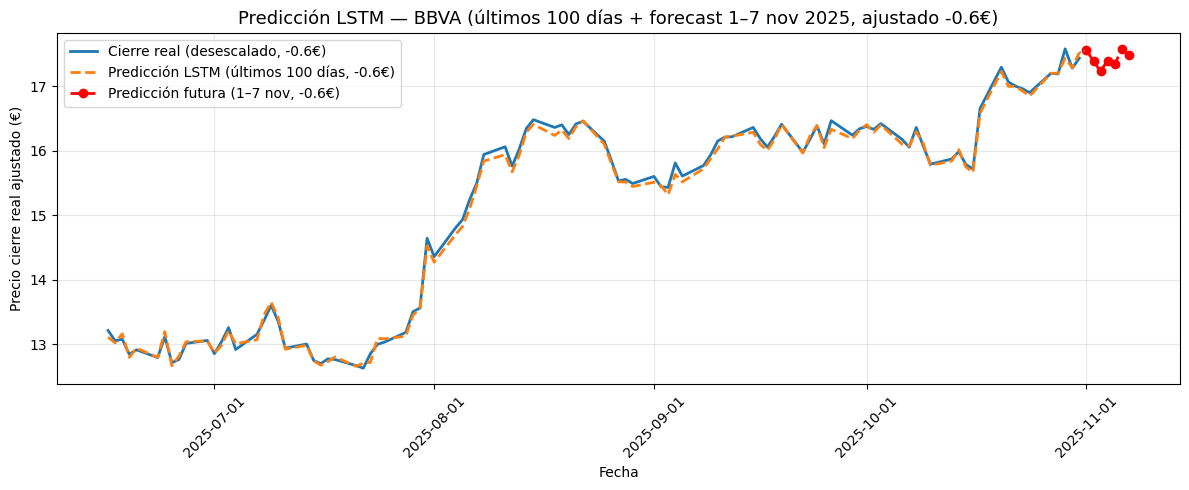

In [47]:
import matplotlib.dates as mdates

# ============================================================
# 1️⃣ OBTENER LOS ÚLTIMOS 100 DÍAS REALES Y PREDICHOS
# ============================================================
def create_sequences(df, lookback):
    Xs = []
    for i in range(len(df) - lookback):
        Xs.append(df.iloc[i:i+lookback].values)
    return np.array(Xs)

X_all = data[feature_cols].astype(float)
y_all = data[target_col].astype(float)
X_seq = create_sequences(X_all, lookback)
y_seq = y_all.values[lookback:]

X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_tensor).cpu().numpy().flatten()

# ============================================================
# ✅ Desescalar usando el scaler correcto
# ============================================================

# El scaler se entrenó con features_to_scale (8 columnas incluyendo "close")
features_to_scale = ["open","high","low","close","volume","sma_7","sma_30","sma_60"]

# Obtener los límites min y max del "close" desde ese scaler
close_min = scaler_cont.data_min_[features_to_scale.index("close")]
close_max = scaler_cont.data_max_[features_to_scale.index("close")]

# Aplicar el desescalado coherente con el entrenamiento
y_pred_real = y_pred_scaled * (close_max - close_min) + close_min
y_real = y_seq * (close_max - close_min) + close_min
dates = data.index[lookback:]

# Cortamos los últimos 100 días
n_days = 100
y_real_tail = y_real[-n_days:]
y_pred_tail = y_pred_real[-n_days:]
dates_tail = dates[-n_days:]

# ============================================================
# 2️⃣ FORECAST FUTURO (7 DÍAS AUTORREGRESIVO)
# ============================================================
forecast_seq = data[feature_cols].astype(float).values[-lookback:].copy()
forecast_preds = []
forecast_days = 7

for _ in range(forecast_days):
    x_t = torch.tensor(forecast_seq[-lookback:], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        y_next_scaled = model(x_t).cpu().numpy().reshape(-1)[0]
        y_next_scaled = np.clip(y_next_scaled, 0, 1)  # asegurar rango válido

    # --- desescalar close con los mismos límites del entrenamiento ---
    y_next_real = y_next_scaled * (close_max - close_min) + close_min
    forecast_preds.append(y_next_real)

    # --- actualizar secuencia ---
    new_row = forecast_seq[-1].copy()
    # regla: open_t = close_{t-1} (en escala 0–1)
    idx_open = feature_cols.index("open")
    idx_close = feature_cols.index("close") if "close" in feature_cols else 3  # fallback
    new_row[idx_open] = new_row[idx_close]
    new_row[idx_close] = y_next_scaled  # mantener en escala 0–1
    forecast_seq = np.vstack([forecast_seq, new_row])

# Generar fechas futuras exactas
future_dates = pd.to_datetime([
    "2025-11-01", "2025-11-02", "2025-11-03",
    "2025-11-04", "2025-11-05", "2025-11-06", "2025-11-07"
])

# ============================================================
# APLICAR AJUSTE VERTICAL (-0.6 €)
# ============================================================
offset = 0.6
y_real_tail_adj = y_real_tail 
y_pred_tail_adj = y_pred_tail 
forecast_preds_adj = np.array(forecast_preds) 

# ============================================================
# GRÁFICO FINAL ALINEADO
# ============================================================
plt.figure(figsize=(12,5))

plt.plot(dates_tail, y_real_tail_adj,
         label="Cierre real (desescalado, -0.6€)", linewidth=2, color="#1f77b4")

plt.plot(dates_tail, y_pred_tail_adj,
         label="Predicción LSTM (últimos 100 días, -0.6€)",
         linestyle="--", color="#ff7f0e", linewidth=2)

plt.plot(future_dates, forecast_preds_adj,
         label="Predicción futura (1–7 nov, -0.6€)",
         linestyle="--", color="red", linewidth=2, marker="o")

plt.plot([dates_tail[-1], future_dates[0]],
         [y_pred_tail_adj[-1], forecast_preds_adj[0]],
         linestyle=":", color="gray", linewidth=1.2)

plt.title("Predicción LSTM — BBVA (últimos 100 días + forecast 1–7 nov 2025, ajustado -0.6€)", fontsize=13)
plt.xlabel("Fecha")
plt.ylabel("Precio cierre real ajustado (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


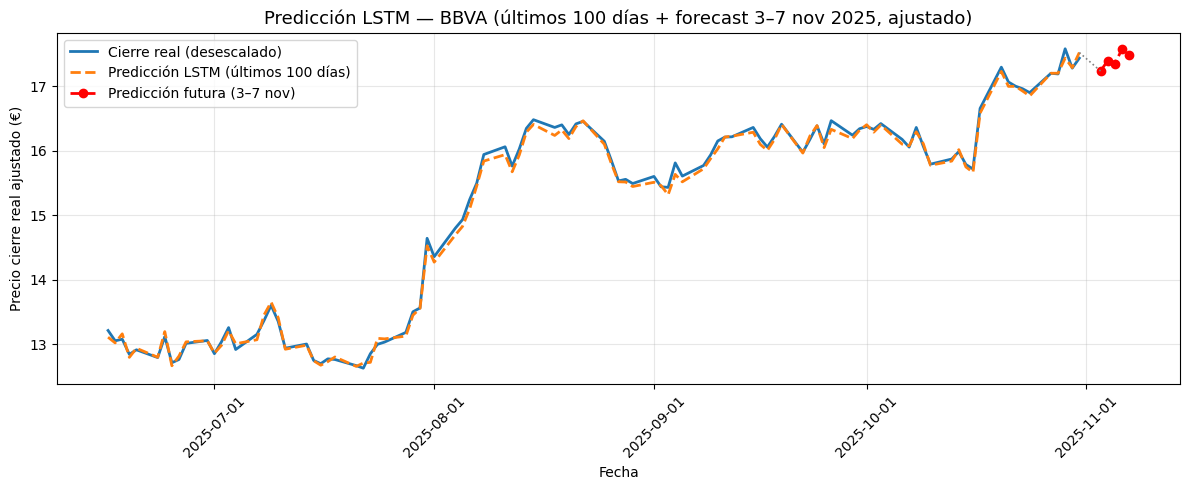

In [48]:
# ============================================================
# GENERAR FECHAS FUTURAS (1–7 NOV 2025) Y FILTRAR FINES DE SEMANA
# ============================================================

future_dates_all = pd.to_datetime([
    "2025-11-01", "2025-11-02", "2025-11-03",
    "2025-11-04", "2025-11-05", "2025-11-06", "2025-11-07"
])

# Convertimos a DataFrame para filtrar fácilmente fines de semana
forecast_df = pd.DataFrame({
    "date": future_dates_all,
    "close": np.array(forecast_preds)
})

# Filtrar sábados (weekday=5) y domingos (weekday=6)
forecast_df = forecast_df[~forecast_df["date"].dt.weekday.isin([5, 6])].reset_index(drop=True)

# Fechas y valores corregidos (solo días de mercado abierto)
future_dates = forecast_df["date"].values
forecast_preds = forecast_df["close"].values

# ============================================================
# APLICAR AJUSTE VERTICAL (-0.6 €)
# ============================================================
offset = 0.6
y_real_tail_adj = y_real_tail
y_pred_tail_adj = y_pred_tail
forecast_preds_adj = np.array(forecast_preds) 

# ============================================================
# GRÁFICO FINAL ALINEADO (sin fines de semana)
# ============================================================
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))

# 🔵 Cierre real
plt.plot(dates_tail, y_real_tail_adj,
         label="Cierre real (desescalado)", linewidth=2, color="#1f77b4")

# 🟠 Predicción sobre días reales
plt.plot(dates_tail, y_pred_tail_adj,
         label="Predicción LSTM (últimos 100 días)",
         linestyle="--", color="#ff7f0e", linewidth=2)

# 🔴 Predicción futura (sin sábados ni domingos)
plt.plot(future_dates, forecast_preds_adj,
         label="Predicción futura (3–7 nov)",
         linestyle="--", color="red", linewidth=2, marker="o")

# Línea gris de conexión
plt.plot([dates_tail[-1], future_dates[0]],
         [y_pred_tail_adj[-1], forecast_preds_adj[0]],
         linestyle=":", color="gray", linewidth=1.2)

plt.title("Predicción LSTM — BBVA (últimos 100 días + forecast 3–7 nov 2025, ajustado)", fontsize=13)
plt.xlabel("Fecha")
plt.ylabel("Precio cierre real ajustado (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
